# Evaluación del modelo de detección de transacciones fraudulentas

Este notebook registra la evaluación del modelo elegido por `train.py`: 
1. Se revisa la selección entre los candidatos de la búsqueda de hiperparámetros (solo validación)
2. Se mide el desempeño en el conjunto de prueba, que no se usó para entrenar ni para elegir el modelo (Generalización).
3. Análisis de la importancia de las características para el modelo final.

## 0. Notas sobre el entrenamiento

Decisiones tomadas en `train.py` que condicionan lo que se puede leer en este notebook:

| Decisión | Detalle | Efecto aquí |
| --- | --- | --- |
| Partición temporal | Por semanas: la última se reserva para prueba (`test_weeks` = 2) y la anterior para validación (`val_weeks` = 1) | Prueba no se usó ni para entrenar ni para elegir nada, así que mide generalización a un período futuro |
| Preprocesamiento | Ajustado solo con entrenamiento (`umbral_otros` = 300). Las categorías poco frecuentes o no vistas caen en el grupo "otros" | Validación y prueba se transforman con el mismo preprocesador guardado; no se reajusta nada |
| Búsqueda | 50 candidatos muestreados con `ParameterSampler` (`random_state` = 88) sobre la grilla de `config.json` | La tabla `tuning.csv` de la sección 1 son esos 50 candidatos, medidos solo en validación |
| Umbral | Elegido en validación como el que maximiza la ganancia, buscando entre 0.01 y 0.99 | Se aplica sin cambios en prueba; no se vuelve a optimizar |
| Selección | El candidato con mayor ganancia en validación | La comparación con otros criterios (sección 1) es posterior y no cambia el modelo guardado |

Artefactos que consume este notebook, todos generados por el entrenamiento: `modelo.pkl`
(preprocesador, modelo, umbral y códigos de "otros"), `tuning.csv`, `predicciones_val.csv`
y `metricas_val.json`.


In [1]:
import os
import json
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score

from ml_fraud_detection.datasets import TARGET_COLUMN, load_dataset, out_of_time_split
from ml_fraud_detection.metrics import best_threshold, evaluate, profit, profit_std
from ml_fraud_detection.predict import load_artifacts, predict_proba

## 1. Configuración

In [2]:
ROOT = "../"
paleta_color = "muted"
colores = sns.color_palette(paleta_color)

with open(os.path.join(ROOT, "config.json")) as f:
    config = json.load(f)
negocio = config["business-rules"]
rutas = {nombre: os.path.join(ROOT, ruta)
         for nombre, ruta in config["inference"].items()}


In [3]:
# Cargar artefactos y resultados de entrenamiento
artefactos = load_artifacts(rutas["artifacts"])
umbral = artefactos["threshold"]
tuning = pd.read_csv(rutas["tuning_results"])
pred_val = pd.read_csv(rutas["val_predictions"], parse_dates=["fecha"])
with open(rutas["val_metrics"]) as f:
    metricas_val = json.load(f)

print("### MEJOR MODELO (CRITERIO GANANCIA) ###")
print(f"\nUmbral de decisión: {umbral:.2f}")
print("Hiperparámetros:", artefactos["params"])


### MEJOR MODELO (CRITERIO GANANCIA) ###

Umbral de decisión: 0.68
Hiperparámetros: {'num_leaves': 30, 'n_estimators': 350, 'min_data_in_leaf': 100, 'learning_rate': 0.05, 'class_weight': 'balanced', 'random_state': 88}


In [4]:
def metricas(pred: pd.DataFrame, umbral: float) -> dict:
    """Métricas de negocio y de clasificación de un conjunto con 
    un umbral dado.
    """
    monto, y_true = pred["monto"].values, pred[TARGET_COLUMN].values
    y_pred = (pred["proba"] >= umbral).astype(int).values
    m = evaluate(monto, y_true, y_pred, **negocio)
    m["mejora_%"] = m["mejora"] / m["ganancia_aprobar_todo"] * 100
    m["ganancia_std"] = profit_std(monto, y_true, y_pred, **negocio)
    m["ap"] = average_precision_score(y_true, pred["proba"])
    return m

## 2. Selección entre modelos candidatos

El entrenamiento elige el candidato con mayor ganancia en el split de validación. 

Para identificar otros posibles candidatos se usa la desviación estándar de la ganancia, que
mide la variabilidad probable del resultado calculada remuestrando 500 veces las transacciones de
validación y calculando la ganancia con las mismas predicciones del modelo (simular un set de datos similar). 

Se consideran empatados los candidatos cuya ganancia está a menos de una desviación estándar
del mejor, es decir, aquellos que este criterio no alcanza a separar del elegido.

Entre esos candidatos empatados se revisa si alguno detecta más fraude (`recall`,
`recall_monto`) o sobreajusta menos (`brecha_ap` = AP entrenamiento − AP validación).

> * Este análisis es posterior a la selección y no cambia el modelo guardado. Es un tamizaje rápido, no una prueba estadística. 
> * `recall_monto`: porcentaje del monto de las transacciones fraudulentas que el modelo rechaza.


In [5]:
# Calculo de diff entre el AP de entrenamiento y validación - indicador de sobreajuste -
tuning["brecha_ap"] = tuning["ap_train"] - tuning["ap"]

# Modelo elegido en train
mejor = tuning.loc[tuning["ganancia"].idxmax()]
tuning["empatado"] = tuning["ganancia"] >= mejor["ganancia"] - mejor["ganancia_std"]
print(f"Mejor ganancia {mejor['ganancia']:,.0f} ± {mejor['ganancia_std']:,.0f}: "
      f"{tuning['empatado'].sum()} de {len(tuning)} candidatos empatados")

columnas = ["ganancia", "ganancia_std", "recall_monto", "recall", "fpr", "ap", "brecha_ap", "umbral"]
hiper = list(artefactos["params"])

# 10 primero Candidatos con mayor ganancia
tuning.sort_values("ganancia", ascending=False)[hiper + columnas + ["empatado"]].head(10).round(3)


Mejor ganancia 173,034 ± 3,753: 28 de 50 candidatos empatados


,num_leaves,n_estimators,min_data_in_leaf,learning_rate,class_weight,random_state,ganancia,ganancia_std,recall_monto,recall,fpr,ap,brecha_ap,umbral,empatado
0,30,350,100,0.05,balanced,88,173034.070,3752.882,0.716,0.589,0.062,0.477,0.114,0.68,True
1,30,350,200,0.10,balanced,88,172682.282,4613.657,0.649,0.537,0.047,0.469,0.223,0.69,True
2,60,150,50,0.05,balanced,88,172592.760,3394.876,0.760,0.632,0.076,0.476,0.097,0.65,True
3,15,350,100,0.05,balanced,88,172247.038,3714.201,0.694,0.563,0.055,0.476,0.044,0.73,True
4,30,200,50,0.10,balanced,88,172027.008,4438.649,0.709,0.608,0.070,0.474,0.137,0.65,True
5,60,200,200,0.10,balanced,88,171981.528,4786.019,0.602,0.466,0.031,0.476,0.258,0.73,True
6,15,250,50,0.05,balanced,88,171911.050,3666.068,0.714,0.589,0.062,0.477,0.026,0.72,True
7,15,150,200,0.10,balanced,88,171622.590,3902.757,0.660,0.527,0.045,0.479,0.030,0.76,True
8,60,250,100,0.05,balanced,88,171589.075,4538.930,0.671,0.558,0.052,0.477,0.172,0.68,True
9,8,300,200,0.05,balanced,88,171309.070,3924.361,0.662,0.536,0.050,0.473,0.006,0.76,True


In [6]:
# 3 modelos con diff criterio de selección
empatados = tuning[tuning["empatado"]]
pd.DataFrame({
    "Mayor ganancia (elegido)": mejor,
    "Mayor recall_monto": empatados.loc[empatados["recall_monto"].idxmax()],
    "Menor brecha AP": empatados.loc[empatados["brecha_ap"].idxmin()],
}).loc[hiper + columnas]


,Mayor ganancia (elegido),Mayor recall_monto,Menor brecha AP
num_leaves,30,8,8
n_estimators,350,200,300
min_data_in_leaf,100,50,200
learning_rate,0.05,0.1,0.05
class_weight,balanced,balanced,balanced
random_state,88,88,88
ganancia,173034.07,169860.28,171309.07
ganancia_std,3752.882367,3480.884721,3924.361437
recall_monto,0.715645,0.768722,0.661895
recall,0.588502,0.663389,0.535552


In [7]:
# Alternativa de selección - ordenar por 3 metricas objetivo
objetivos = ["ganancia", "recall_monto", "recall"]
rango = empatados[objetivos].rank(ascending=False).mean(axis=1)

print("Empatados, ordenados por el promedio de sus puestos en las tres métricas:")
empatados.assign(rango_promedio=rango).sort_values("rango_promedio")[
    hiper + objetivos + ["rango_promedio", "brecha_ap", "umbral"]
].head(5).round(3)

Empatados, ordenados por el promedio de sus puestos en las tres métricas:


,num_leaves,n_estimators,min_data_in_leaf,learning_rate,class_weight,random_state,ganancia,recall_monto,recall,rango_promedio,brecha_ap,umbral
2,60,150,50,0.05,balanced,88,172592.760,0.760,0.632,2.333,0.097,0.65
0,30,350,100,0.05,balanced,88,173034.070,0.716,0.589,6.667,0.114,0.68
4,30,200,50,0.10,balanced,88,172027.008,0.709,0.608,7.000,0.137,0.65
6,15,250,50,0.05,balanced,88,171911.050,0.714,0.589,8.500,0.026,0.72
25,8,200,50,0.10,balanced,88,169860.280,0.769,0.663,9.333,0.020,0.66


**Conclusión.**
* 28 de los 50 candidatos quedan a menos de una desviación estándar (3,753) del mejor,
así que la ganancia en validación no basta para distinguirlos con este criterio.
* Entre los empatados hay alternativas con mejor perfil de negocio. El candidato de 8 hojas
detecta 76.9% del monto de las transacciones fraudulentas, frente a 71.6% del elegido, y 
cuesta $3,174 de ganancia.
* El criterio combinado (promedio de puestos en `ganancia`, `recall_monto` y `recall`) señala
un candidato distinto: 60 hojas y 150 árboles, con 172,593 de ganancia. Pierde solo $441
frente al elegido, poco más de una décima de desviación, y a cambio detecta 4.4 puntos más
de monto en fraude (76.0% vs 71.6%) y 4.3 puntos más de fraudes (63.2% vs 58.9%).
* El elegido tampoco es el que mejor generaliza: su `brecha_ap` es 0.114, mientras varios
empatados están por debajo de 0.03 con un AP en validación prácticamente igual (0.472–0.477).

Se mantiene el modelo elegido por el entrenamiento, porque el criterio de máxima ganancia se
definió antes de ver los resultados y es el que responde a la regla de negocio del enunciado.

Estas alternativas quedan documentadas como opciones si el negocio prioriza detectar más
fraude por encima de la ganancia esperada.

## 3. Desempeño en validación y prueba

El umbral se eligió en validación y se aplica sin cambios en prueba.

In [8]:
df = load_dataset(os.path.join(ROOT, config["data"]["path"]))
_, _, test = out_of_time_split(df, config["data"]["val_weeks"], config["data"]["test_weeks"])

pred_test = test[["fecha", "monto", "score", TARGET_COLUMN]].assign(proba=predict_proba(test, artefactos))
print(f"Test: {pred_test['fecha'].min().date()} a {pred_test['fecha'].max().date()} | {len(pred_test):,} transacciones")


Test: 2020-04-13 a 2020-04-21 | 35,494 transacciones


In [9]:
resultados = pd.DataFrame({"validación": metricas(pred_val, umbral), "test": metricas(pred_test, umbral)})
resultados.round(4)

,validación,test
ganancia,173034.0700,269328.6150
ganancia_aprobar_todo,128268.7725,226254.4550
mejora,44765.2975,43074.1600
tp,778.0000,925.0000
fp,1432.0000,2225.0000
tn,21689.0000,31698.0000
fn,544.0000,646.0000
tasa_aprobacion,0.9096,0.9113
recall,0.5885,0.5888
precision,0.3520,0.2937


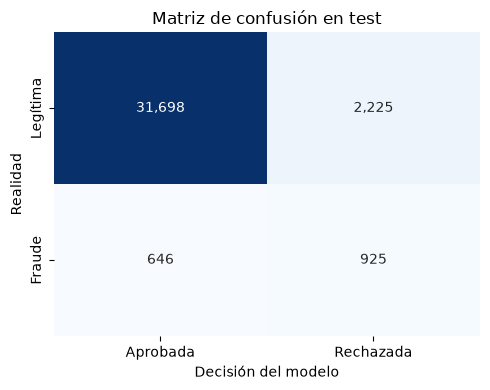

In [10]:
m = resultados["test"]
matriz = pd.DataFrame(
    [[m["tn"], m["fp"]], [m["fn"], m["tp"]]],
    index=["Legítima", "Fraude"], columns=["Aprobada", "Rechazada"],
).astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(matriz, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax)
ax.set(xlabel="Decisión del modelo", ylabel="Realidad", title="Matriz de confusión en test")
plt.tight_layout()
plt.show()

In [11]:
volumen = pd.DataFrame({
    "validación": {"transacciones": len(pred_val), "tasa de fraude %": pred_val[TARGET_COLUMN].mean() * 100},
    "test": {"transacciones": len(pred_test), "tasa de fraude %": pred_test[TARGET_COLUMN].mean() * 100},
}).T
volumen["mejora"] = resultados.loc["mejora"]
volumen["mejora por transacción"] = volumen["mejora"] / volumen["transacciones"]
volumen.round(2)


,transacciones,tasa de fraude %,mejora,mejora por transacción
validación,24443.0,5.41,44765.30,1.83
test,35494.0,4.43,43074.16,1.21


**Conclusión.**
* El modelo generaliza al período siguiente: en prueba gana $269,329 frente a $226,254 de aprobar todo, es decir $43,074 más. 
* La detección de fraude se comporta igual con el mismo umbral de 0.68: el recall es prácticamente idéntico (58.9% en ambos) y la tasa de aprobación pasa de 91.0% a 91.1%.
* Lo que sí se deteriora es la calidad de los rechazos: la precisión baja de 35.2% a 29.4% y el `recall_monto`
de 71.6% a 67.6%.

## 4. Sobreajuste

Average precision (AP) no depende del umbral, por lo que permite comparar la capacidad
de ordenar el riesgo en los tres conjuntos.

In [12]:
pd.Series({
    "train": metricas_val["ap_train"],
    "validación": resultados.loc["ap", "validación"],
    "test": resultados.loc["ap", "test"],
}, name="average precision").round(4)


train         0.5911
validación    0.4773
test          0.4376
Name: average precision, dtype: float64

**Conclusión.** 
> Se usa el *AP (average precision)* como métrica de diagnóstico de sobreajuste, ya que no depende del umbral. No como criterio de selección.

* El AP cae de 0.591 en entrenamiento a 0.477 en validación: una brecha de 0.114 que indica un sobreajuste moderado. 
* La caída de validación a prueba es menor (0.039), así que su capacidad de clasificar el fraude se sostiene en el
período siguiente.

Si se quiere evitar este nivel de sobreajsute, es posible seleccionar otro modelo entre los candidatos con menor brecha de AP, que pierden poca ganancia frente al elegido.

## 5. Importancia de variables

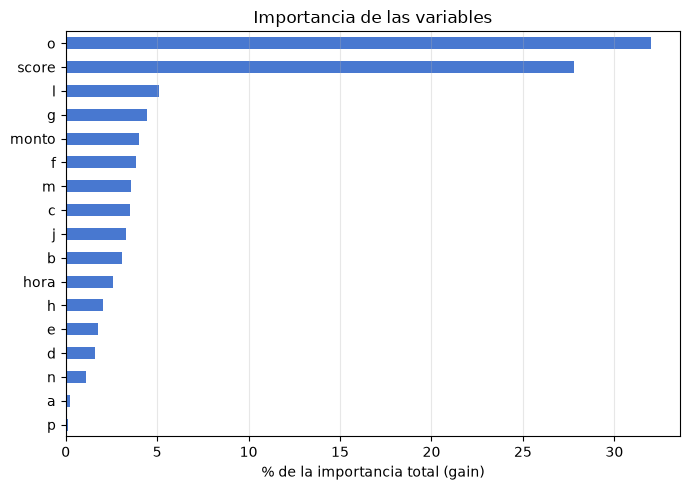

o        32.0
score    27.8
l         5.1
g         4.4
monto     4.0
f         3.8
m         3.6
c         3.5
j         3.3
b         3.1
hora      2.6
h         2.0
e         1.7
d         1.6
n         1.1
a         0.2
p         0.1
dtype: float64

In [13]:
modelo = artefactos["model"]
importancia = pd.Series(
    modelo.booster_.feature_importance("gain"), index=modelo.booster_.feature_name()
).sort_values()
importancia = importancia / importancia.sum() * 100

fig, ax = plt.subplots(figsize=(7, 5))
importancia.plot.barh(ax=ax, color=colores[0])
ax.set(xlabel="% de la importancia total (gain)", title="Importancia de las variables")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

importancia.sort_values(ascending=False).round(1)


**Conclusión.**
* La importancia está muy concentrada: `o` aporta 32.0% de la ganancia total de los árboles y
`score` 27.8%. Entre las dos explican el 60% del modelo.
* Que `score` pese tanto confirma que el modelo se apoya en la señal de riesgo que ya existía,
pero no depende solo de ella: excluyendo la importancia de `o`, el 40% restante se reparte entre 15 variables.

> La importancia por *gain* mide cuánto ayudó cada variable a separar las clases dentro de los
> árboles. No indica la dirección del efecto ni implica causalidad.


In [14]:
rechazadas = pred_test["proba"] >= umbral
fp = rechazadas & (pred_test[TARGET_COLUMN] == 0)
tp = rechazadas & (pred_test[TARGET_COLUMN] == 1)

descomposicion = pd.Series({
    "Pérdida por fraude evitada": pred_test.loc[tp, "monto"].sum(),
    "Margen sacrificado en legítimas": -negocio["margin"] * pred_test.loc[fp, "monto"].sum(),
})
descomposicion["Mejora neta"] = descomposicion.sum()
descomposicion.round(0)


Pérdida por fraude evitada         79828.0
Margen sacrificado en legítimas   -36754.0
Mejora neta                        43074.0
dtype: float64

## Conclusiones Finales

**El modelo aporta valor de negocio medible.** En el período de prueba, que no se usó para
entrenar ni para elegir nada, la ganancia pasa de $226,254 aprobando todo a $269,329: un
aumento de $43,074 (+19.0%).

**El costo de esa ganancia es rechazar el 8.9% de las transacciones.** Con el umbral de 0.68
el modelo detecta 58.9% de los fraudes y 67.6% del monto fraudulento, a cambio de rechazar por
error 6.6% de las transacciones legítimas. Este "falso rechazo" equivale a $36,754 de margen en
2,225 transacciones legítimas. 

**La elección del modelo es robusta en ganancia, pero no única.** Entre los 28 candidatos empatados
hay alternativas que detectan hasta 5 puntos más de monto fraudulento con un sacrificio en la ganancia bajo.
Si el negocio prioriza detectar fraude por encima de la ganancia esperada, esas alternativas son defendibles
sin reabrir la búsqueda.
